# Анализ рынка заведений общественного питания в Москве.

- Автор:Никитина Полина


### Цели и задачи проекта
**Цель проекта:** провести исследовательский анализ рынка зведений общественного питания в Москве. 

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
    - изучить данные более детально;
    - изучить соотношение сетевый и несетевых заведений;
    - исследовать рейтинг заведений и факторы от которого он зависит;
    - найти топ-15 популярных сетей в Москве;
    - изучить ценовую политику заведений в Москве.
4. Сформулировать выводы по проведённому анализу.
<font color='#777778'></font>

### Описание данных

<font color='#777778'>
    
Файл /здесь должна быть ссылка содержит информацию о заведениях общественного питания:
    
- name — название заведения;
- address — адрес заведения;
- district — административный район, в котором находится заведение, например Центральный административный округ;
- category — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- hours — информация о днях и часах работы;
- rating — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- chain — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
0 — заведение не является сетевым;
1 — заведение является сетевым.
- seats — количество посадочных мест.
    
Файл /здесь должна быть ссылка содержит информацию о среднем чеке в заведениях общественного питания:
    
- price — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- avg_bill — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:
    - «Средний счёт: 1000–1500 ₽»;
    - «Цена чашки капучино: 130–220 ₽»;
    - «Цена бокала пива: 400–600 ₽».
    - и так далее;
- middle_avg_bill — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- middle_coffee_cup — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.</font>

### Содержимое проекта

<font color='#777778'>

    
1. Загрузка данных и знакомство с ними
    - Промежуточный вывод
    - Подготовка единого датафрейма
2. Предобработка данных
    
    - Промежуточный вывод
    
3. Исследовательский анализ данных
    
    - Задача 1
    - Задача 2
    - Задача 3
    - Задача 4
    - Задача 5
    - Задача 6
    - Задача 7
    - Задача 8
    - Промежуточный вывод
    
4. Итоговый вывод и рекомендации
    </font>

---

## Загрузка данных и знакомство с ними

- Загрузите данные о заведениях общественного питания Москвы. Путь к файлам: `/datasets/rest_info.csv` и `/datasets/rest_price.csv`.

In [1]:
# загружаем библитеки
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

!pip install phik
from phik import phik_matrix

     |████████████████████████████████| 686 kB 1.4 MB/s eta 0:00:01


In [2]:
data='https://code.s3.yandex.net/datasets/'

In [3]:
# смотрим данные /здесь должна быть ссылка и /здесь должна быть ссылкаinfo_df=pd.read_csv(здесь должна быть ссылка)
price_df=pd.read_csv(здесь должна быть ссылка')

In [4]:
# смотрим первые строки датасета info_df
info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [5]:
# смотрим данные датасета info_df
info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [6]:
# смотрим первые строки датасета price_df
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [7]:
# смотрим данные датасета info_df
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


### Подготовка единого датафрейма

- Объедините данные двух датасетов в один, с которым вы и продолжите работу.

In [8]:
# объединяем два датасета в один, используем левое соелинение, так как в первом датасете большее количество строк
rest_df = info_df.merge(price_df, how='left', on='id')

In [9]:
rest_df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


Объединили датасеты, оставив всю информациюю из левого, так как в нем большее количество строк.

## Предобработка данных

Подготовим данные к исследовательскому анализу:

- Изучаем корректность типов данных, при необходимости проведем их преобразование.

In [10]:
# смотрим информацию об объндтненном датасете
rest_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


In [11]:
# меняем разрядность столбцов

# Меняем тип данных столбца rating - уменьшаем разрядность
rest_df['rating'] = pd.to_numeric(rest_df['rating'], downcast='float')

# Меняем тип данных столбца chain - уменьшаем разрядность
rest_df['chain'] = pd.to_numeric(rest_df['chain'], downcast='integer')

In [12]:
rest_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float32
 7   chain              8406 non-null   int8   
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float32(1), float64(3), int8(1), object(8)
memory usage: 829.1+ KB


РАЗОЯДНОСТЬ ПОМЕНЯЛА НИЖЕ, НЕ ВНЕСЛА В ЭТИ КОММЕНТАРИИ

- Изучим пропущенные значения в данных: считаем их количество в каждом столбце датафрейме, изучим данные с пропущенными значениями и предположим гипотезы их появления. Проведем обработку пропущенных значений.

In [13]:
# смотрим количество пропусков
rest_df.isna().sum().sort_values(ascending=False)

middle_coffee_cup    7871
middle_avg_bill      5257
price                5091
avg_bill             4590
seats                3611
hours                 536
id                      0
name                    0
category                0
address                 0
district                0
rating                  0
chain                   0
dtype: int64

In [14]:
# смотрим процент пропусков
((rest_df.isna().sum() / len(rest_df)) * 100).sort_values(ascending=False)




middle_coffee_cup    93.635498
middle_avg_bill      62.538663
price                60.563883
avg_bill             54.603854
seats                42.957411
hours                 6.376398
id                    0.000000
name                  0.000000
category              0.000000
address               0.000000
district              0.000000
rating                0.000000
chain                 0.000000
dtype: float64

In [15]:
# смотрим уникальные значения ы столбцах hours, seats 
for column in ['hours', 'seats']:
    print (f'Уникальные значения в столбце{column}:')
    print(rest_df[column].sort_values().unique())
    print

Уникальные значения в столбцеhours:
['Нет информации'
 'вт 08:30–17:00; ср,чт 12:00–20:30; пт 08:30–17:00; сб 09:00–16:30'
 'вт 13:00–21:00; ср 11:00–20:00; чт 13:00–21:00; пт-вс 11:00–20:00' ...
 'чт круглосуточно, перерыв 10:00–20:00; сб круглосуточно'
 'чт-вс 20:00–06:00' nan]
Уникальные значения в столбцеseats:
[0.000e+00 1.000e+00 2.000e+00 3.000e+00 4.000e+00 5.000e+00 6.000e+00
 7.000e+00 8.000e+00 9.000e+00 1.000e+01 1.200e+01 1.300e+01 1.400e+01
 1.500e+01 1.600e+01 1.700e+01 1.800e+01 1.900e+01 2.000e+01 2.100e+01
 2.200e+01 2.400e+01 2.500e+01 2.600e+01 2.700e+01 2.800e+01 2.900e+01
 3.000e+01 3.200e+01 3.300e+01 3.400e+01 3.500e+01 3.600e+01 3.700e+01
 3.800e+01 3.900e+01 4.000e+01 4.100e+01 4.200e+01 4.300e+01 4.400e+01
 4.500e+01 4.600e+01 4.700e+01 4.800e+01 4.900e+01 5.000e+01 5.100e+01
 5.200e+01 5.300e+01 5.400e+01 5.500e+01 5.600e+01 5.800e+01 6.000e+01
 6.100e+01 6.200e+01 6.300e+01 6.400e+01 6.500e+01 6.600e+01 6.700e+01
 6.800e+01 6.900e+01 7.000e+01 7.200e+01 7.4

In [16]:
# заменим значения nan в столбце hours на Нет информации
rest_df['hours'].fillna('Нет информации', inplace=True)

Посмотрим явные дубликаты

In [17]:
# смотрим явные дубликаты
rest_df.duplicated().sum()


0

Явных дубликатов нет, теперь стоит проверить неявные дубликаты при наличии удалим эти строки, приведем данные к одному регистру и удалим пробелы.

In [18]:
# приводим столбцы к одному регистру и удаляем пробелы
rest_df['name']=rest_df['name'].str.lower().str.strip()
rest_df['address']=rest_df['address'].str.lower().str.strip()

In [19]:
duplicates = rest_df.duplicated(subset=['name', 'address'], keep=False).sum()
print (duplicates)


8


Посмотрим на дубликаты

In [20]:
duplicates = rest_df[rest_df.duplicated(subset=['name', 'address'], keep=False)]
print(duplicates)



                                    id                       name  category  \
189   072032ce16dc47bfbc63b672c75bd371                       кафе      кафе   
215   897ddbc6746c4388b19dc8a9fcdbb488                       кафе      кафе   
1430  62608690e9cc464fbcd980cfd552e334                  more poke  ресторан   
1511  a69f018d5c064873a3b491b0121bc1b4                  more poke  ресторан   
2211  c6ef39ae8a8c483d8f9a6531bc386a2c  раковарня клешни и хвосты  ресторан   
2420  aba1de7ad7d64ac0a3f8684bda29d905  раковарня клешни и хвосты   бар,паб   
3091  3c2a73ea79a04be48858fab3685f2f37            хлеб да выпечка  булочная   
3109  d3116844e4e048f99614eb30be3214e0            хлеб да выпечка      кафе   

                                      address  \
189              москва, парк ангарские пруды   
215              москва, парк ангарские пруды   
1430  москва, волоколамское шоссе, 11, стр. 2   
1511  москва, волоколамское шоссе, 11, стр. 2   
2211               москва, проспект мира, 1

Неявных дубликатов выявлено 8, данные задвоены, возможно данные щаведения меняли какие-либо свои общие показатели их задвоили, удаляем


In [21]:
# удаляем дубликаты
rest_df = rest_df.drop_duplicates(subset=['name', 'address'])


- Для дальнейшей работы создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [22]:
# создаем доп стобец
"""
функция def проверяет столбец hours, при отсутствии данных принимает значение False, при наличии данных ежедневно и круглосуточно 
"""
def is_24_7(hours):
    if pd.isna(hours):
        return False
    if any(phrase in hours for phrase in ['ежедневно, круглосуточно']):
        return True
    return False
rest_df['is_24_7'] = rest_df['hours'].apply(is_24_7)    

##  Исследовательский анализ данных
Проведем исследовательский анализ исходных данных.

При исследовании данных используем визуализации. Проверим, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---

### Задача 1

Посмотрим какие категории заведений есть в датасете, посчитаем количество. 

In [23]:
rest_df_category=rest_df.groupby('category')['id'].nunique().sort_values()
rest_df_category

category
булочная            256
столовая            315
быстрое питание     603
пиццерия            633
бар,паб             764
кофейня            1413
ресторан           2042
кафе               2376
Name: id, dtype: int64

In [24]:
rest_df_category = rest_df['category'].value_counts(normalize=True) * 100
print(rest_df_category)


кафе               28.278981
ресторан           24.303737
кофейня            16.817424
бар,паб             9.093073
пиццерия            7.533920
быстрое питание     7.176863
столовая            3.749107
булочная            3.046894
Name: category, dtype: float64


Отобразим полученные данные на столбцатой диаграмме

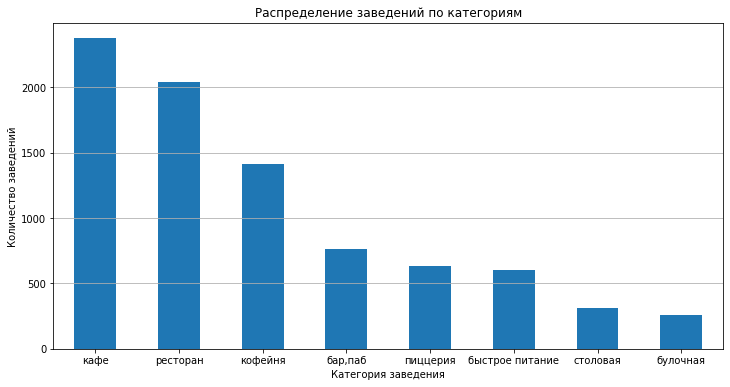

In [25]:
ax = rest_df['category'].value_counts().plot(kind='bar', 
                                             figsize=(12, 6),
                                            legend=False,
                                            rot=0)
ax.set_title('Распределение заведений по категориям')
ax.set_xlabel('Категория заведения')
ax.set_ylabel('Количество заведений')
plt.grid(axis='y')
plt.show()

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

Сгруппируем данные по административным районам, отдельно рассмотрим распределение заведений каждой категории в Центральном административном округе Москвы.

Посмотрим общее количество заведений в представленных административных округах. Построим график для наглядности

In [26]:
#Группируем по округу и считаем количество заведений, сортируем по количеству
rest_df.groupby('district')['id'].nunique().sort_values()


district
Северо-Западный административный округ      409
Юго-Западный административный округ         709
Юго-Восточный административный округ        714
Восточный административный округ            798
Западный административный округ             850
Северо-Восточный административный округ     890
Южный административный округ                892
Северный административный округ             898
Центральный административный округ         2242
Name: id, dtype: int64

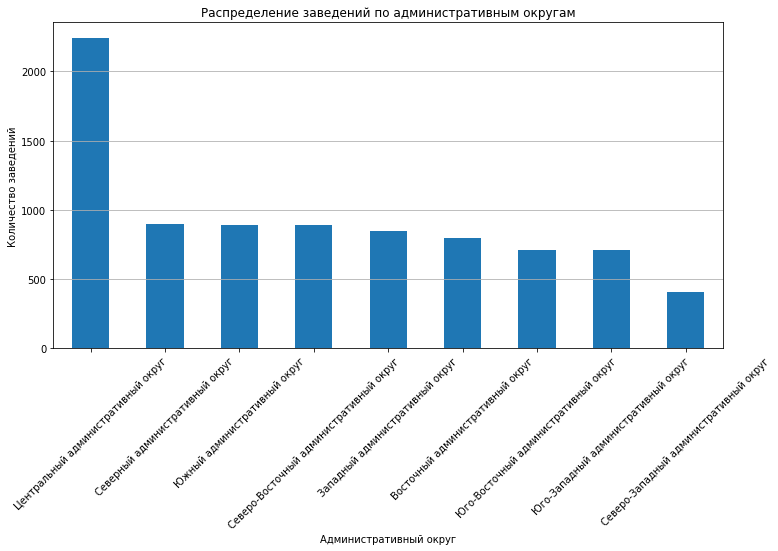

In [27]:
ax = rest_df['district'].value_counts().plot(kind='bar', 
                                             figsize=(12, 6),
                                            legend=False,
                                            rot=45)
ax.set_title('Распределение заведений по административным округам')
ax.set_xlabel('Административный округ')
ax.set_ylabel('Количество заведений')
plt.grid(axis='y')
plt.show()

Посмотрим на распределение данных по ЦАО.

In [28]:
"""
функция def сортирует по ЦАО, далее группирует по категориям и применяет фунуцию к нашему датасету
"""
def count_cao(rest_df):
    cao_df = rest_df[rest_df['district'] == 'Центральный административный округ']
    category_counts = cao_df['category'].value_counts()
    return category_counts

# Предположим, что у вас уже есть датафрейм rest_df
category_counts = count_cao(rest_df)
print(category_counts)


ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64


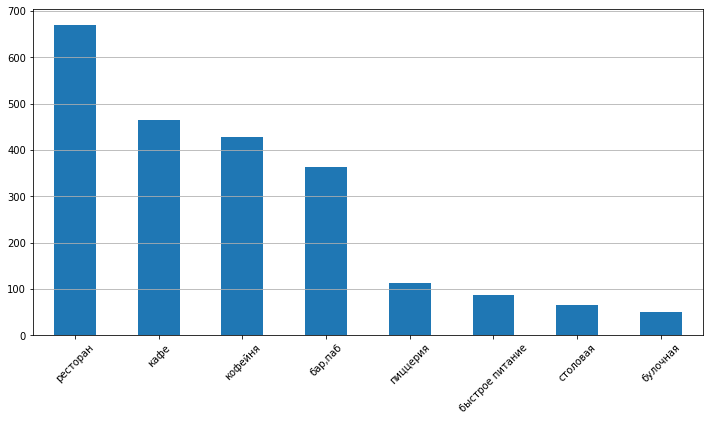

In [29]:
cao_df = rest_df[rest_df['district'] == 'Центральный административный округ']
ax_cao = cao_df['category'].value_counts().plot(kind='bar', 
                                             figsize=(12, 6),
                                            legend=False,
                                            rot=45)
ax.set_title('Распределение заведений по ЦАО')
ax.set_xlabel('Административный округ')
ax.set_ylabel('Количество заведений')
plt.grid(axis='y')
plt.show()

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

Посмотрим в целом долю сетевых и несетевых магазинов

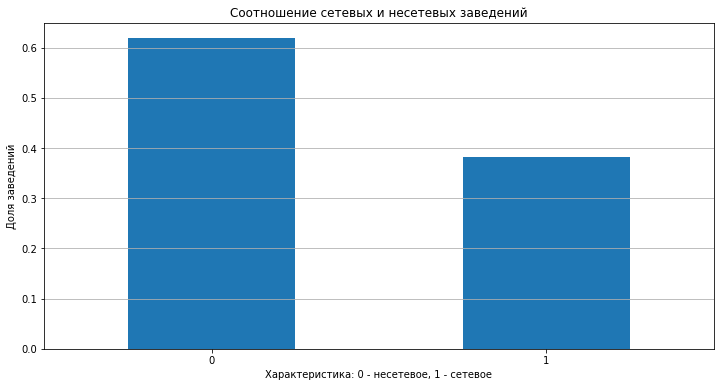

Соотношение сетевых и несетевых заведений:


0    0.618781
1    0.381219
Name: chain, dtype: float64

In [30]:
rest_df['chain'].value_counts(normalize=True).plot(
    kind='bar',
    figsize=(12, 6),
    rot=0,
    title=f'Соотношение сетевых и несетевых заведений'
)
plt.xlabel('Характеристика: 0 - несетевое, 1 - сетевое')
plt.ylabel('Доля заведений')
plt.grid(axis='y')
plt.show()
print('Соотношение сетевых и несетевых заведений:')
rest_df['chain'].value_counts(normalize=True)

Построим визуализацию, которая отобразит количество сетевых и несетевых магазинов по категориям.

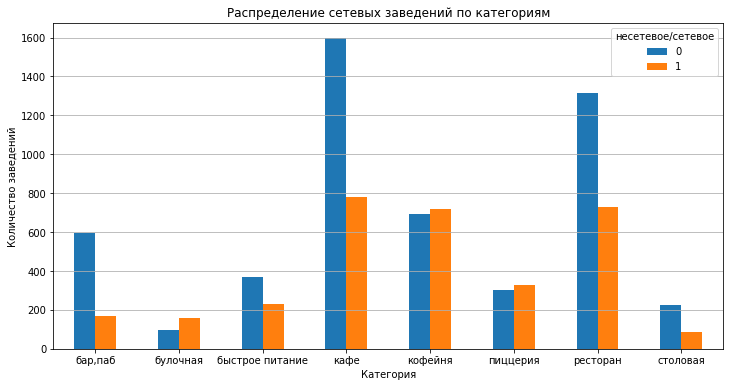

chain  category       
1      столовая             88
0      булочная             99
1      булочная            157
       бар,паб             168
0      столовая            227
1      быстрое питание     232
0      пиццерия            303
1      пиццерия            330
0      быстрое питание     371
       бар,паб             596
       кофейня             693
1      кофейня             720
       ресторан            729
       кафе                779
0      ресторан           1313
       кафе               1597
Name: id, dtype: int64

In [31]:
"""
столбчатая диаграмма группирует по признаку из столбца chain, группирует по столбцу category, 
"""
df_unstack = rest_df.groupby('category')['chain'].value_counts().unstack(fill_value=0)

# Строим столбчатую диаграмму
df_unstack.plot(kind='bar',figsize=(12, 6))
# Настраиваем график
plt.grid(axis='y') # сетка по оси х
plt.title('Распределение сетевых заведений по категориям') # Заголовок диаграммы
plt.ylabel('Количество заведений') # Подписываем ось Y
plt.xlabel('Категория') # Подписываем ось X
plt.xticks(rotation=0)  # Оставляем метки оси X горизонтальными
plt.legend(title='несетевое/сетевое')  # Легенда для разбивки по `Products`

# Отображаем график
plt.show()
# Отображаем график
plt.show()
# считаем кол-во стетвых и несетевых магазинов
rest_df.groupby(['chain', 'category'])['id'].nunique().sort_values()
 

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


Посмотрим среднее и медиану посадочных мест с группировкой по категориям заведений

In [32]:
rest_df.groupby('category')['seats'].agg(['median', 'mean']) # смотрим моду по столбцу seats в ращрезе каждой категории

,median,mean
category,,
"бар,паб",82.0,124.477516
булочная,50.0,89.385135
быстрое питание,65.0,98.891117
кафе,60.0,97.365653
кофейня,80.0,111.199734
пиццерия,55.0,94.496487
ресторан,86.0,121.892041
столовая,75.5,99.750000


Визуализируем расчеты

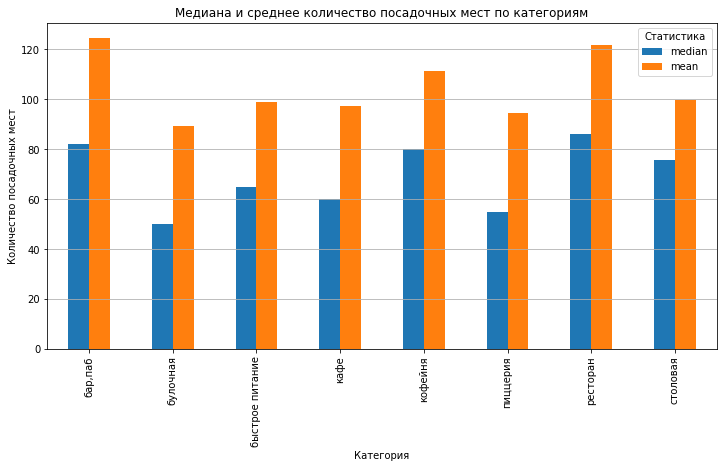

In [33]:
grouped = rest_df.groupby('category')['seats'].agg(['median', 'mean']) # группируем по категориям и считаем медиану и среднее

grouped.plot(kind='bar', figsize=(12, 6))
plt.grid(axis='y')
plt.title('Медиана и среднее количество посадочных мест по категориям')
plt.xlabel('Категория')
plt.ylabel('Количество посадочных мест')
plt.legend(title='Статистика')
plt.show()

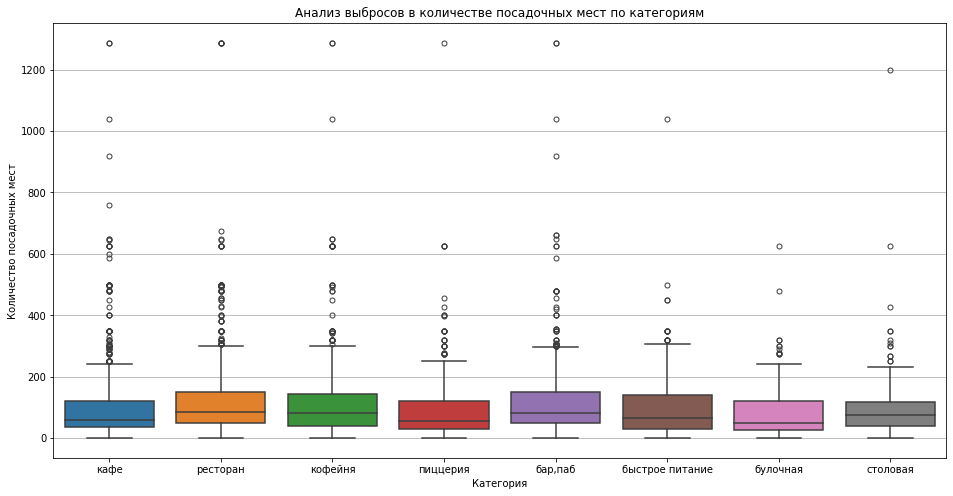

In [34]:
sns.boxplot(x='category', y='seats', data=rest_df, whis=1.5, flierprops={'marker': 'o', 'markerfacecolor': 'none', 'markersize': 5})
plt.title('Анализ выбросов в количестве посадочных мест по категориям')
plt.xlabel('Категория')
plt.ylabel('Количество посадочных мест')
plt.gcf().set_size_inches(16, 8) 
plt.grid(axis='y')  
plt.show()

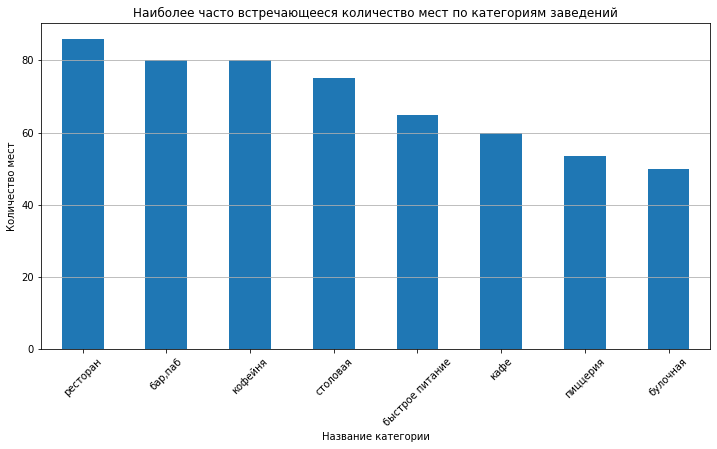

'Наиболее типичное количество мест по категориям заведений:'

,category,seats
6,ресторан,86.0
0,"бар,паб",80.0
4,кофейня,80.0
7,столовая,75.0
2,быстрое питание,65.0
3,кафе,60.0
5,пиццерия,54.0
1,булочная,50.0


In [35]:
median_seats = rest_df[rest_df['seats'] <= 800].groupby('category')['seats'].median().reset_index()
median_seats.sort_values(by='seats', ascending=False).plot(
     kind='bar',
     x='category',
     y='seats',
     legend=False,
    figsize=(12, 6),
    rot=45
)
plt.title('Наиболее часто встречающееся количество мест по категориям заведений')
plt.ylabel('Количество мест')
plt.xlabel('Название категории')
plt.grid(axis='y')
plt.show()
display('Наиболее типичное количество мест по категориям заведений:')
round(median_seats.sort_values(by='seats', ascending=False), 0)


---

### Задача 5

Посмотрим рейтинг заведений, проанализируем есть ли отличия среднего рейтинга в разрезе категорий.

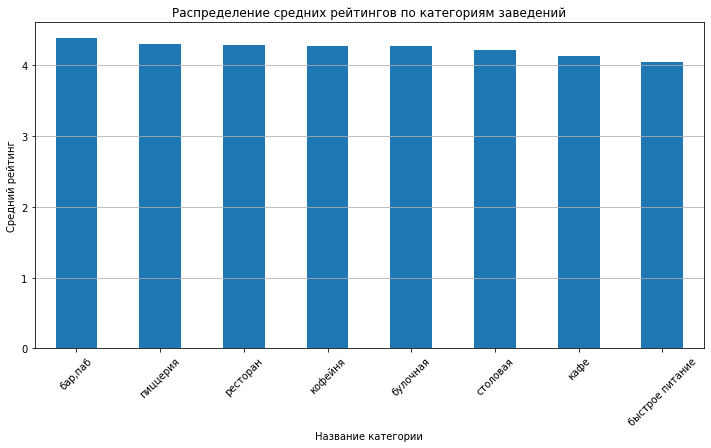

'Распределение средних рейтингов по категориям заведений:'

category
бар,паб            4.39
пиццерия           4.30
ресторан           4.29
кофейня            4.28
булочная           4.27
столовая           4.21
кафе               4.12
быстрое питание    4.05
Name: rating, dtype: float32


In [36]:
"""
строим столбчатую диаграмму, группируем по категории и считаем средний рейтинг
"""
df_rating = rest_df.groupby('category')['rating'].mean()
df_rating.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(12, 6),
    legend=False,
    rot=45
)

plt.title('Распределение средних рейтингов по категориям заведений')
plt.ylabel('Средний рейтинг')
plt.xlabel('Название категории')
plt.grid(axis='y')
plt.show()

display('Распределение средних рейтингов по категориям заведений:')
print(round(df_rating, 2).sort_values(ascending=False))


В каждой категории средний рейтинг не опускается ниже 4. Самый высокий средний рейтинг у баров 4,39

---

### Задача 6

Изучим, с какими данными показывают самую сильную корреляцию рейтинги заведений. Построим и визуализируем матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Посмотрим самую сильную связь и проверим её.

In [37]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = rest_df[['category', 'district', 'rating',
       'chain', 'seats', 'price', 'is_24_7']].phik_matrix()

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной rating:')
print(correlation_matrix.loc[correlation_matrix.index != 'rating', ['rating']].sort_values(by='rating', ascending=False))


interval columns not set, guessing: ['rating', 'chain', 'seats']
Корреляционная матрица с коэффициентом phi_k для переменной rating:
            rating
price     0.262056
category  0.198739
district  0.189453
is_24_7   0.161010
chain     0.118857
seats     0.000000


Самая большая корреляция наблюдается со столбцом цена. Построим тепловую карту.

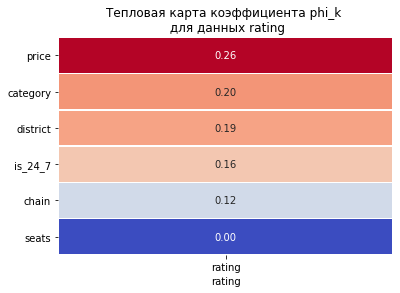

In [38]:

data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, 
            fmt='.2f',
            cmap='coolwarm', 
            linewidths=0.5, 
            cbar=False
           )


plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.xlabel('rating')


plt.show()

Самая сильная корреляция с ценой подтвердилась, проверим ее

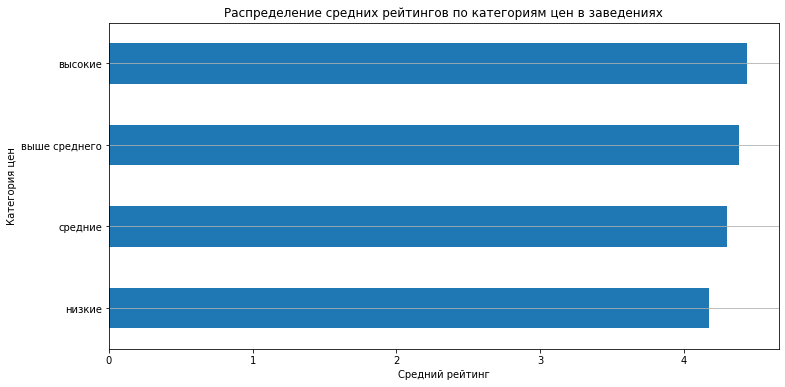

Распределение рейтингов по категориям цен в заведениях


,price,rating
0,высокие,4.436611
1,выше среднего,4.386348
3,средние,4.297874
2,низкие,4.173077


In [39]:
rest_df_1= rest_df.groupby('price')['rating'].agg('mean').reset_index()
rest_df_1.sort_values(by='rating', ascending=True).plot(
    kind='barh',
    x='price',
    y='rating',
    legend=False,
    figsize=(12,6)
)
plt.title('Распределение средних рейтингов по категориям цен в заведениях')
plt.ylabel('Категория цен')
plt.xlabel('Средний рейтинг')
plt.grid(axis='y')
plt.show()
print('Распределение рейтингов по категориям цен в заведениях')
rest_df_1.sort_values(by='rating', ascending=False)


In [40]:
rest_df_summary = rest_df[rest_df['chain'] == 1].groupby('name').agg(
    count=('name', 'size'), 
    average_rating=('rating', 'mean'),
    category=('category', 'first')
).sort_values(by='count', ascending=False)

print(rest_df_summary.head(15))


                                     count  average_rating         category
name                                                                       
шоколадница                            120        4.177500          кофейня
домино'с пицца                          76        4.169737         пиццерия
додо пицца                              74        4.286487         пиццерия
one price coffee                        71        4.064789          кофейня
яндекс лавка                            69        3.872464         ресторан
cofix                                   65        4.075385          кофейня
prime                                   50        4.116000         ресторан
хинкальная                              44        4.322727  быстрое питание
кофепорт                                42        4.147619          кофейня
кулинарная лавка братьев караваевых     39        4.394872             кафе
теремок                                 38        4.123684         ресторан
чайхана     

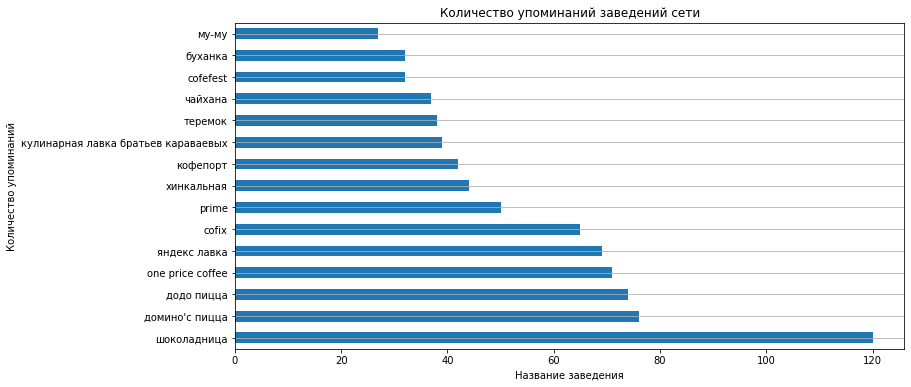

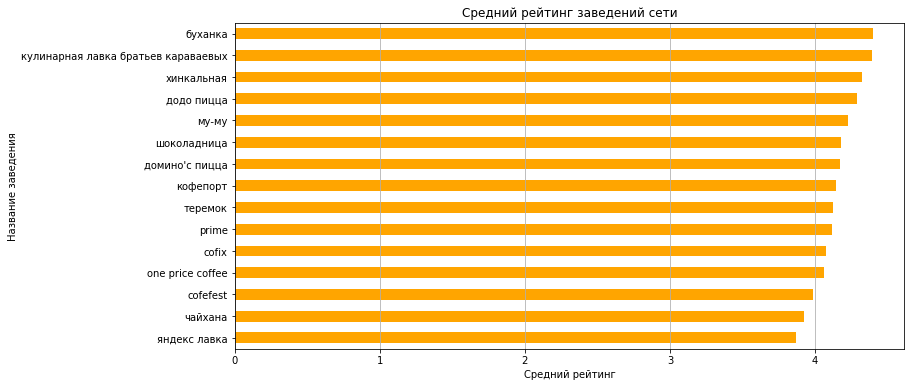

In [41]:

rest_df_summary = rest_df[rest_df['chain'] == 1].groupby('name').agg(
    count=('name', 'size'),
    average_rating=('rating', 'mean'),
    category=('category', 'first')
).sort_values(by='count', ascending=False)
# Визуализация количества упоминаний
rest_df_summary['count'].head(15).plot(kind='barh', 
                                       figsize=(12, 6))
plt.title('Количество упоминаний заведений сети')
plt.xlabel('Название заведения')
plt.ylabel('Количество упоминаний')
plt.grid(axis='y')
plt.show()

# Визуализация среднего рейтинга
rest_df_summary['average_rating'].head(15).sort_values(ascending=True).plot(kind='barh', color='orange', figsize=(12, 6))
plt.title('Средний рейтинг заведений сети')
plt.xlabel('Средний рейтинг')
plt.ylabel('Название заведения')
plt.grid(axis='x')
plt.show()

---

### Задача 8

Посмотрим вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируем цены в Центральном административном округе и других. Посмотрим как удалённость от центра влияет на цены в заведениях.


In [42]:
# группируем по округ, считаем среднее
rest_df_avg_bill=rest_df.groupby('district')['middle_avg_bill'].median().sort_values(ascending=False).reset_index()
print(rest_df_avg_bill)

                                  district  middle_avg_bill
0          Западный административный округ           1000.0
1       Центральный административный округ           1000.0
2   Северо-Западный административный округ            700.0
3          Северный административный округ            650.0
4      Юго-Западный административный округ            600.0
5         Восточный административный округ            575.0
6  Северо-Восточный административный округ            500.0
7             Южный административный округ            500.0
8     Юго-Восточный административный округ            450.0


Построим график

Text(0, 0.5, 'Средняя цена')

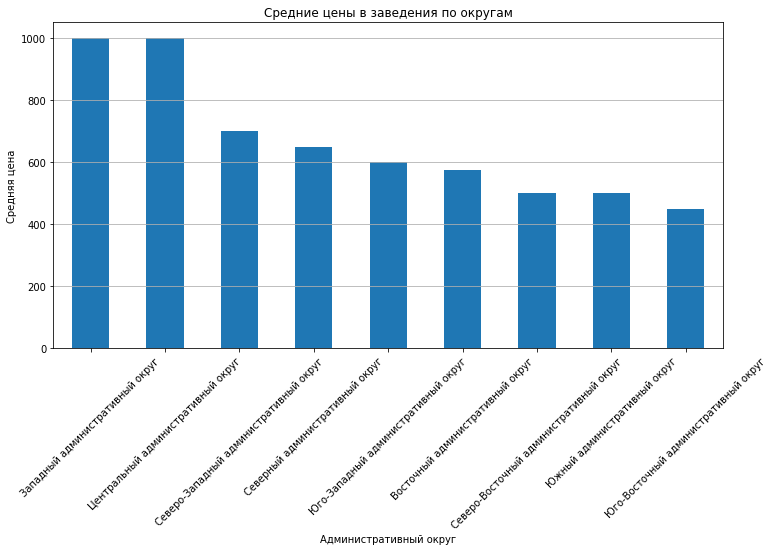

In [43]:
rest_df_avg_bill.plot(kind='bar',
                      x='district',
                      y='middle_avg_bill',
                      rot=45,
                     figsize=(12,6),
                     legend=False)
plt.grid(axis='y')
plt.title('Средние цены в заведения по округам')
plt.xlabel('Административный округ')
plt.ylabel('Средняя цена')
                                                                                                      

Посмотрим основные статистические показатели по ЦАО

In [44]:
rest_df_avg_bill = rest_df[rest_df['district'] == 'Центральный административный округ']['middle_avg_bill'].describe()
rest_df_avg_bill


count    1060.000000
mean     1191.057547
std       920.014707
min         0.000000
25%       500.000000
50%      1000.000000
75%      1500.000000
max      7250.000000
Name: middle_avg_bill, dtype: float64

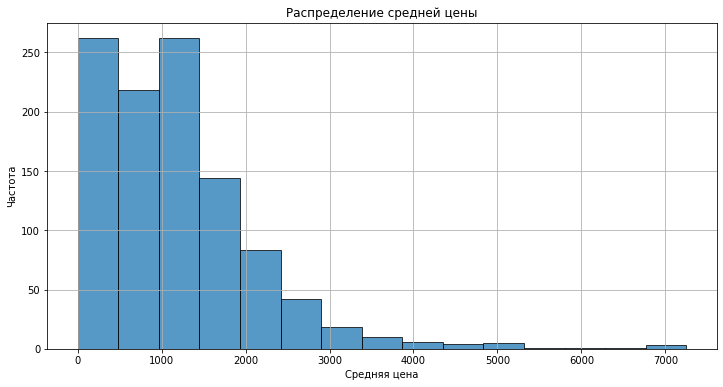

In [45]:
# Строим гистограмму с помощью pandas через plot(kind='hist')
rest_df[rest_df['district'] == 'Центральный административный округ']['middle_avg_bill'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=15, # Устанавливаем количество корзин - всего 25
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
                figsize=(12,6)
)

# Настраиваем оформление графика
plt.title('Распределение средней цены')
plt.xlabel('Средняя цена')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show() 

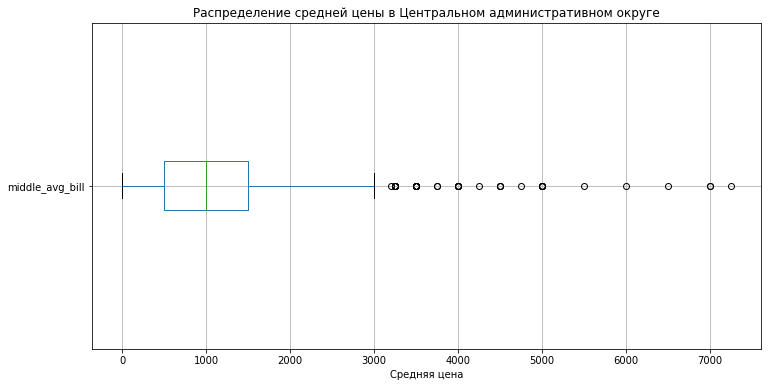

In [46]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Применяем отбор по Центральному административному округу и строим диаграмму размаха значений
rest_df[rest_df['district'] == 'Центральный административный округ'].boxplot(column='middle_avg_bill', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение средней цены в Центральном административном округе')
plt.xlabel('Средняя цена')

# Выводим график
plt.show()
